<a href="https://colab.research.google.com/github/Kate326/qwe/blob/main/HR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Загрузите файл HR.csv в pandas dataframe.

Рассчитайте основные статистики для переменных: среднее, медиана, мода, мин/макс, среднее отклонение.

Рассчитайте и визуализируйте корреляционную матрицу для количественных переменных.

Определите две самые скоррелированные и две наименее скоррелированные переменные.

Рассчитайте, сколько сотрудников работает в каждом департаменте.

Покажите распределение сотрудников по зарплатам.

Покажите распределение сотрудников по зарплатам в каждом департаменте по отдельности.

Проверьте гипотезу, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом.

Рассчитайте следующие показатели среди уволившихся и не уволившихся сотрудников (по отдельности): доля сотрудников с повышением за последние 5 лет; средняя степень удовлетворённости; среднее количество проектов.

Разделите данные на тестовую и обучающую выборки. Постройте модель LDA, которая показывает, уволился ли сотрудник на основе имеющихся факторов (кроме department и salary).

Оцените качество модели на тестовой выборке. Используйте метод accuracy.

In [ ]:
# импортируем все необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# считываем данные из csv-файла в dataframe
df = pd.read_csv('HR.csv')

In [ ]:
# Рассчитайте основные статистики для переменных: среднее, медиана, мода, мин/макс, среднее отклонение
print('Среднее:')
print(df.mean(numeric_only=True))

print('\nМедиана:')
print(df.median(numeric_only=True))

print('\nМода:')
print(df.mode().iloc[0])

print('\nМинимальное значение:')
print(df.min(numeric_only=True))

print('\nМаксимальное значение:')
print(df.max(numeric_only=True))

print('\nСреднее отклонение:')
print(df.std(numeric_only=True))

Среднее:
satisfaction_level         0.612834
last_evaluation            0.716102
number_project             3.803054
average_montly_hours     201.050337
time_spend_company         3.498233
Work_accident              0.144610
left                       0.238083
promotion_last_5years      0.021268
dtype: float64

Медиана:
satisfaction_level         0.64
last_evaluation            0.72
number_project             4.00
average_montly_hours     200.00
time_spend_company         3.00
Work_accident              0.00
left                       0.00
promotion_last_5years      0.00
dtype: float64

Мода:
satisfaction_level         0.1
last_evaluation           0.55
number_project             4.0
average_montly_hours       135
time_spend_company         3.0
Work_accident              0.0
left                       0.0
promotion_last_5years      0.0
department               sales
salary                     low
Name: 0, dtype: object

Минимальное значение:
satisfaction_level        0.09
last_evaluati

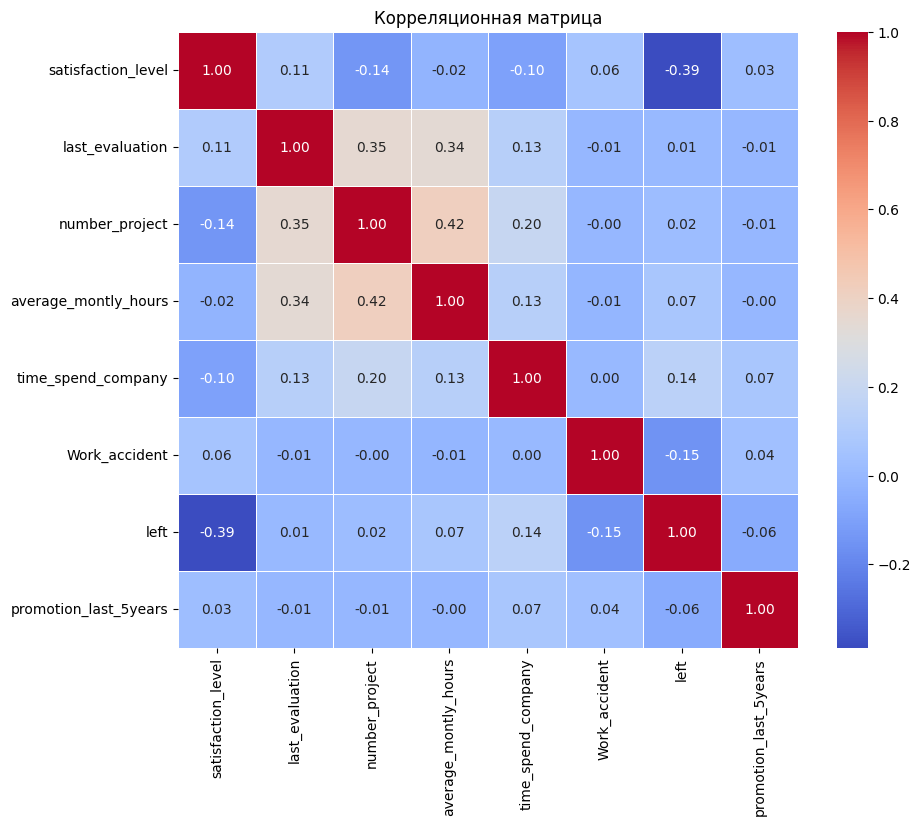

In [ ]:
# Рассчитайте и визуализируйте корреляционную матрицу для количественных переменных
correlation_matrix = df.corr(numeric_only=True)

# визуализация с помощью тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляционная матрица')
plt.show()

In [ ]:
# Определите две самые скоррелированные и две наименее скоррелированные переменные

# берем абсолютные значения и сортируем их по убыванию
pairs = correlation_matrix.abs().unstack().sort_values(ascending=False)

# удаляем единицы (корреляция самой с собой)
pairs = pairs[pairs != 1]

# выводим результат

# две самые скоррелированные
# (первая и третья, пропускаем дубликат)
print('Две самые скоррелированные пары:')
print(pairs[0:3:2])
# две наименее скоррелированные
# третья с конца и последняя, пропускаем дубликат)
print('Две наименее скоррелированные пары')
print(pairs[-4:-1:2])

Две самые скоррелированные пары:
number_project      average_montly_hours    0.417211
satisfaction_level  left                    0.388375
dtype: float64
Две наименее скоррелированные пары
average_montly_hours  promotion_last_5years    0.003544
Work_accident         time_spend_company       0.002120
dtype: float64


In [ ]:
# Рассчитайте, сколько сотрудников работает в каждом департаменте
print(df['department'].value_counts())

department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


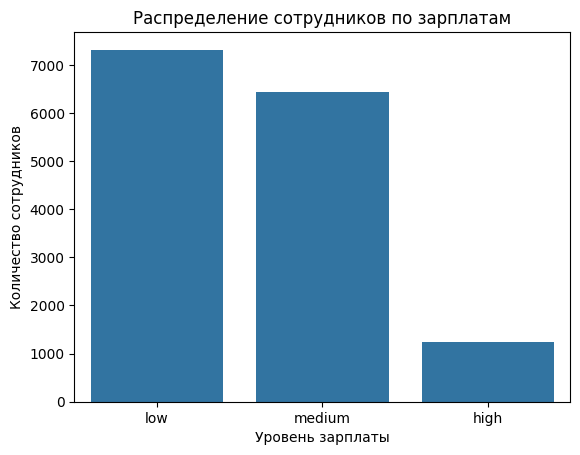

In [ ]:
# Покажите распределение сотрудников по зарплатам
# строим столбчатую диаграмму
plt.figure()
sns.countplot(x='salary', data=df)
plt.title('Распределение сотрудников по зарплатам')
plt.xlabel('Уровень зарплаты')
plt.ylabel('Количество сотрудников')
plt.show()

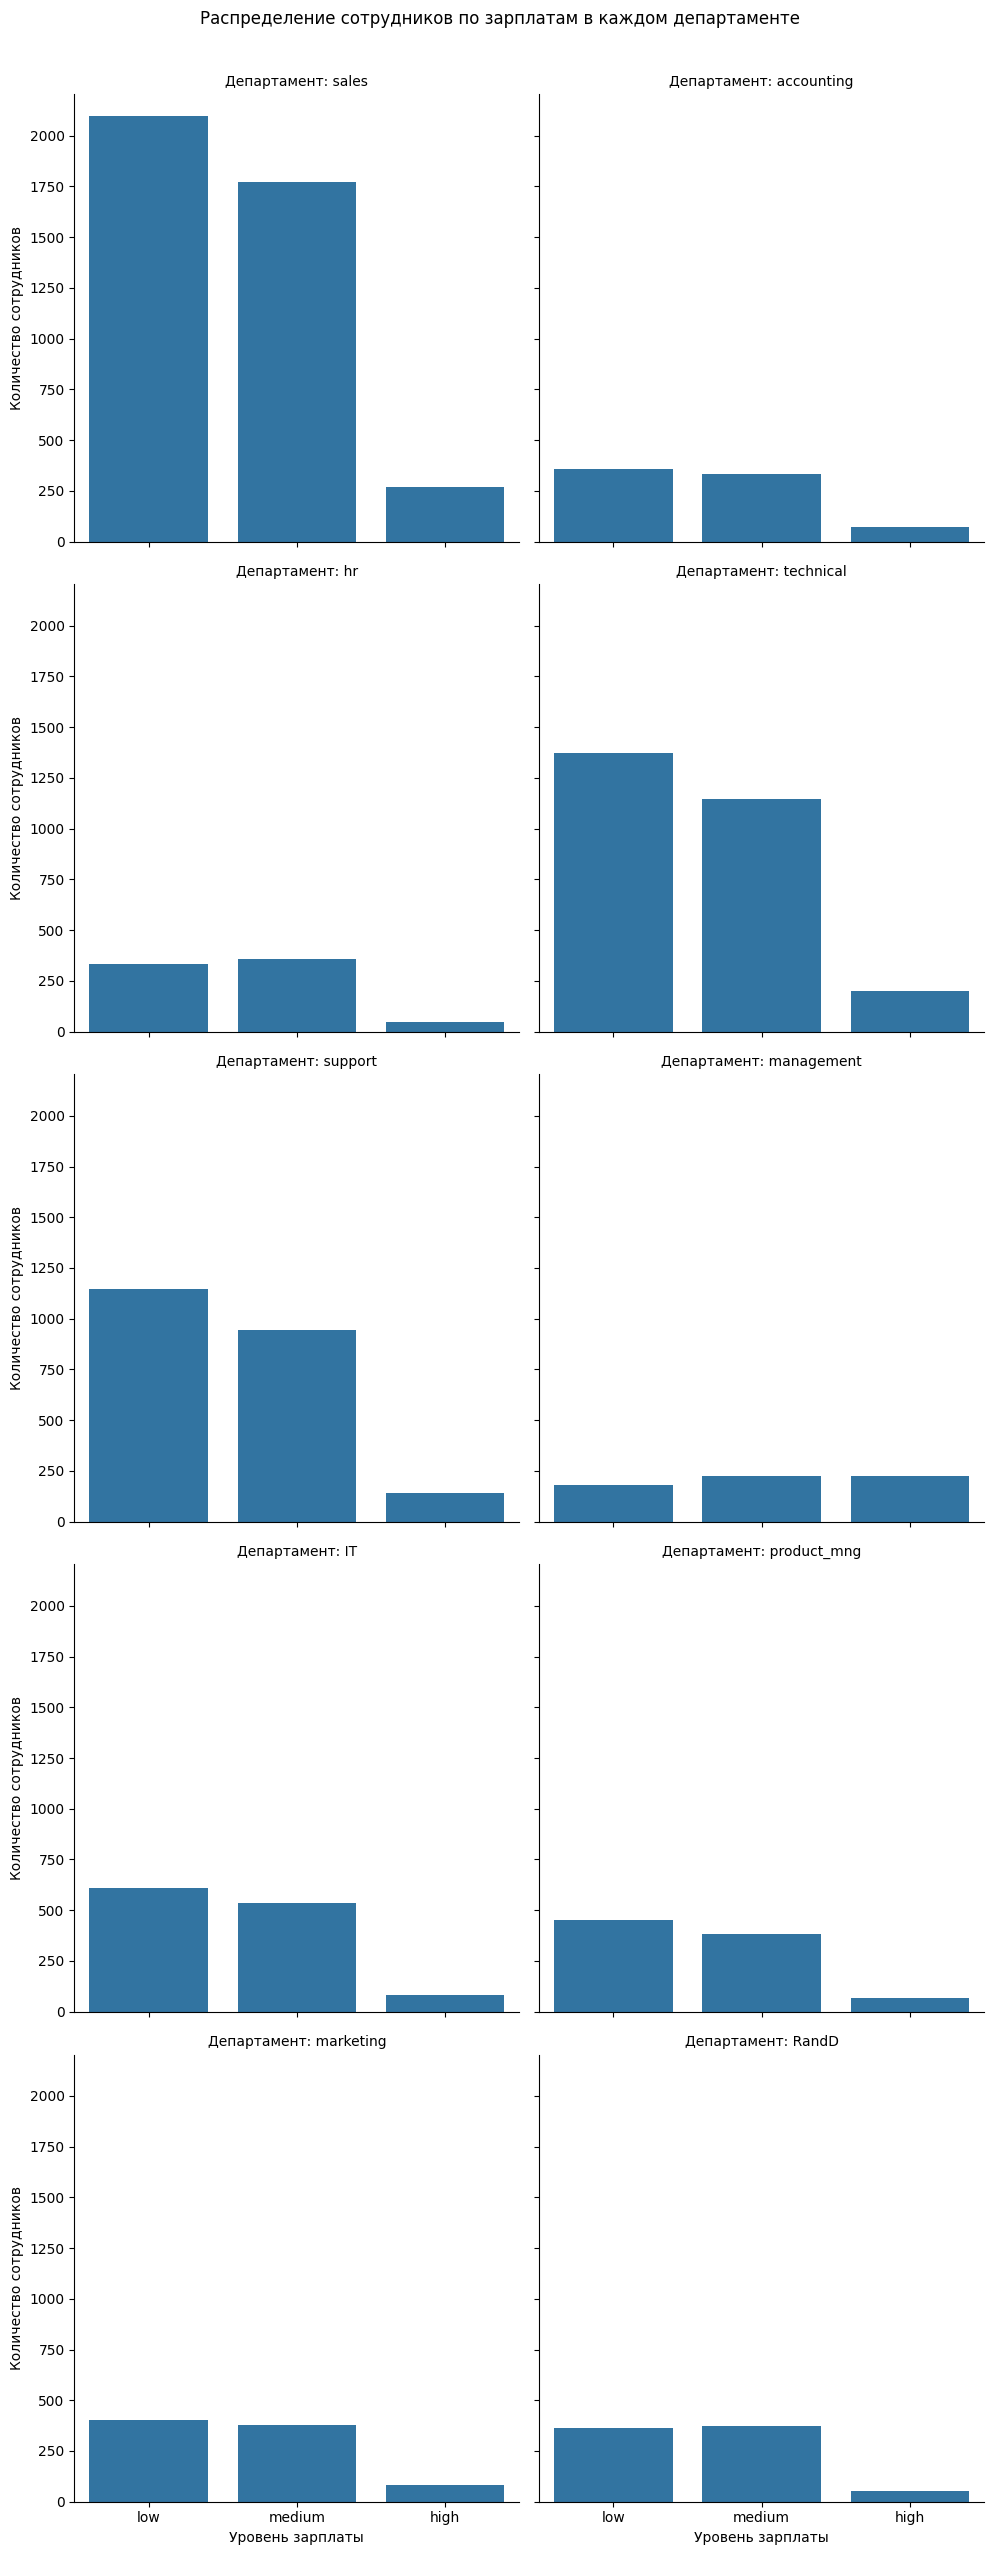

In [ ]:
# Покажите распределение сотрудников по зарплатам в каждом департаменте по отдельности
# строим отдельные диаграммы по департаментам
g = sns.catplot(x='salary', col='department', col_wrap=2, data=df, kind='count')
g.set_axis_labels('Уровень зарплаты', 'Количество сотрудников')
g.set_titles('Департамент: {col_name}')
plt.suptitle('Распределение сотрудников по зарплатам в каждом департаменте', y=1.02)
plt.show()

In [ ]:
# Проверьте гипотезу, что сотрудники с высоким окладом проводят
# на работе больше времени, чем сотрудники с низким окладом

# берем две группы средних часов на работе по уровню зарплаты
high_salary = df[df['salary'] == 'high']['average_montly_hours']
low_salary = df[df['salary'] == 'low']['average_montly_hours']

# проводим t-тест
t_statistic, p_value = stats.ttest_ind(high_salary_hours, low_salary_hours)

# выводим результаты
print(f'Среднее количество часов для высокой зарплаты: {high_salary_hours.mean():.2f}')
print(f'Среднее количество часов для низкой зарплаты: {low_salary_hours.mean():.2f}')
print(f'T-статистика: {t_statistic:.2f}')
print(f'P-значение: {p_value:.3f}')

# проверка гипотезы
if p_value < 0.05:
    # разница статистически значима
    if t_statistic > 0:
        # сотрудники с высоким окладом проводят больше времени на работе
        print('Гипотеза подтверждается')
    else:
        # обратная ситуация
        print('Гипотеза не подтверждается, сотрудники с низким окладом проворят на работе больше времени')
else:
    # нет статистически значимой разницы
    print('Гипотеза не подтверждается, нет статистически значимой разницы в количестве часов')


Среднее количество часов для высокой зарплаты: 199.87
Среднее количество часов для низкой зарплаты: 201.00
T-статистика: -0.73
P-значение: 0.466
Гипотеза не подтверждается, нет статистически значимой разницы в количестве часов


In [ ]:
# Рассчитайте следующие показатели среди уволившихся и не уволившихся сотрудников (по отдельности):
# доля сотрудников с повышением за последние 5 лет;
# средняя степень удовлетворённости;
# среднее количество проектов.

# группируем данные по столбцу left
employee_stats = df.groupby('left').agg(
    promotion=('promotion_last_5years', 'mean'), # доля сотрудников с повышением
    satisfaction=('satisfaction_level', 'mean'), # средняя степень удовлетворенности
    projects=('number_project', 'mean') # среднее количество проектов
)

# Вывод результатов
print("Показатели для уволившихся и не уволившихся сотрудников:")
display(employee_stats)

Показатели для уволившихся и не уволившихся сотрудников:


,promotion,satisfaction,projects
left,,,
0,0.026251,0.666810,3.786664
1,0.005321,0.440098,3.855503


In [ ]:
# Разделите данные на тестовую и обучающую выборки
# Постройте модель LDA, которая показывает, уволился ли сотрудник на основе
# имеющихся факторов (кроме department и salary).
# Оцените качество модели на тестовой выборке. Используйте метод accuracy.

# факторы
X = df.drop(['left', 'department', 'salary'], axis=1)
# зависимая переменная
y = df['left']

# разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y)

# строим модель LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# делаем предсказание
y_pred = lda.predict(X_test)

# оцениваем качество модели
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность модели LDA на тестовой выборке: {accuracy:.4f}")

Точность модели LDA на тестовой выборке: 0.7648
